# Credit Card Fraud Analysis

### Business Problem
Credit card fraud causes significant financial losses for banks and customers. This project analyzes transaction data to understand fraud patterns and identify key insights that can help improve fraud detection.

In [5]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
# Load Dataset

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [7]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21878 entries, 0 to 21877
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    21878 non-null  int64  
 1   V1      21878 non-null  float64
 2   V2      21878 non-null  float64
 3   V3      21878 non-null  float64
 4   V4      21878 non-null  float64
 5   V5      21878 non-null  float64
 6   V6      21878 non-null  float64
 7   V7      21878 non-null  float64
 8   V8      21878 non-null  float64
 9   V9      21878 non-null  float64
 10  V10     21878 non-null  float64
 11  V11     21878 non-null  float64
 12  V12     21878 non-null  float64
 13  V13     21878 non-null  float64
 14  V14     21878 non-null  float64
 15  V15     21878 non-null  float64
 16  V16     21878 non-null  float64
 17  V17     21878 non-null  float64
 18  V18     21878 non-null  float64
 19  V19     21878 non-null  float64
 20  V20     21878 non-null  float64
 21  V21     21878 non-null  float64
 22

In [8]:
# Dataset Shape

print("Rows and Columns:", df.shape)

Rows and Columns: (21878, 31)


In [9]:
# Dataset Shape

print("Rows and Columns:", df.shape)

Rows and Columns: (21878, 31)


In [10]:
# Statistical Summary

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,...,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21877.000000,21877.000000
mean,16924.271551,-0.241060,0.222124,0.737915,0.262153,-0.175227,0.087496,-0.141011,0.019339,0.562079,...,-0.043038,-0.140156,-0.037826,0.010707,0.125683,0.029305,0.011978,0.006293,71.725300,0.003931
std,11005.409549,1.880901,1.518111,1.740947,1.451072,1.414872,1.322606,1.323924,1.383927,1.277273,...,0.849611,0.644914,0.512947,0.590807,0.436855,0.524399,0.395178,0.247253,205.034501,0.062576
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-32.092129,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-3.612114,0.000000,0.000000
25%,5496.250000,-0.960913,-0.350012,0.298029,-0.649075,-0.756733,-0.660688,-0.597972,-0.169171,-0.273362,...,-0.257010,-0.564567,-0.175530,-0.331558,-0.136296,-0.339574,-0.067305,-0.010143,5.990000,0.000000
50%,18770.500000,-0.299205,0.206484,0.888730,0.222271,-0.210143,-0.176618,-0.069763,0.026032,0.515162,...,-0.109913,-0.111903,-0.048576,0.062115,0.163900,-0.042054,0.005402,0.019665,17.430000,0.000000
75%,27778.750000,1.164867,0.858497,1.520365,1.132694,0.332839,0.481047,0.447633,0.281472,1.330385,...,0.059938,0.267688,0.074156,0.399318,0.404503,0.320185,0.095819,0.077587,62.390000,0.000000
max,31907.000000,1.960497,16.713389,4.101716,11.927512,34.099309,21.393069,34.303177,20.007208,10.392889,...,22.614889,5.805795,13.876221,3.695503,5.525093,3.517346,8.254376,4.860769,7879.420000,1.000000


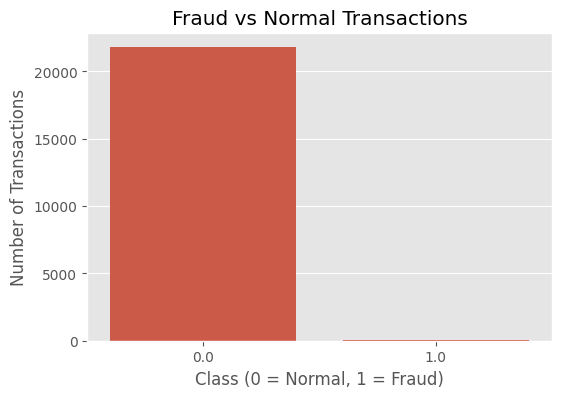

In [11]:
# Fraud vs Normal Transactions

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Class")

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [12]:
# Fraud Percentage

fraud = df["Class"].value_counts()

print(fraud)

print("\nFraud Percentage:")
print((fraud[1] / len(df)) * 100)

Class
0.0    21791
1.0       86
Name: count, dtype: int64

Fraud Percentage:
0.3930889478014444


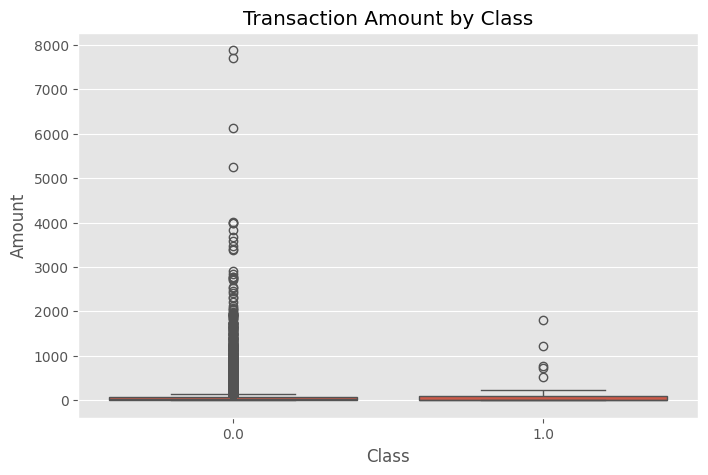

In [13]:
# Transaction Amount Distribution

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

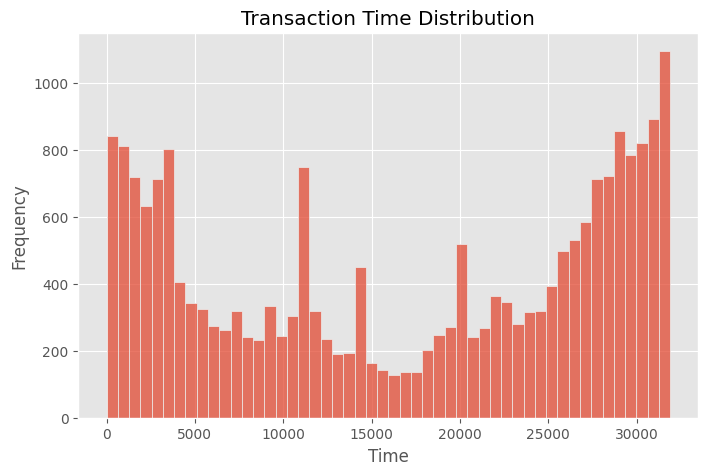

In [14]:
# Transaction Time Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Time"], bins=50)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

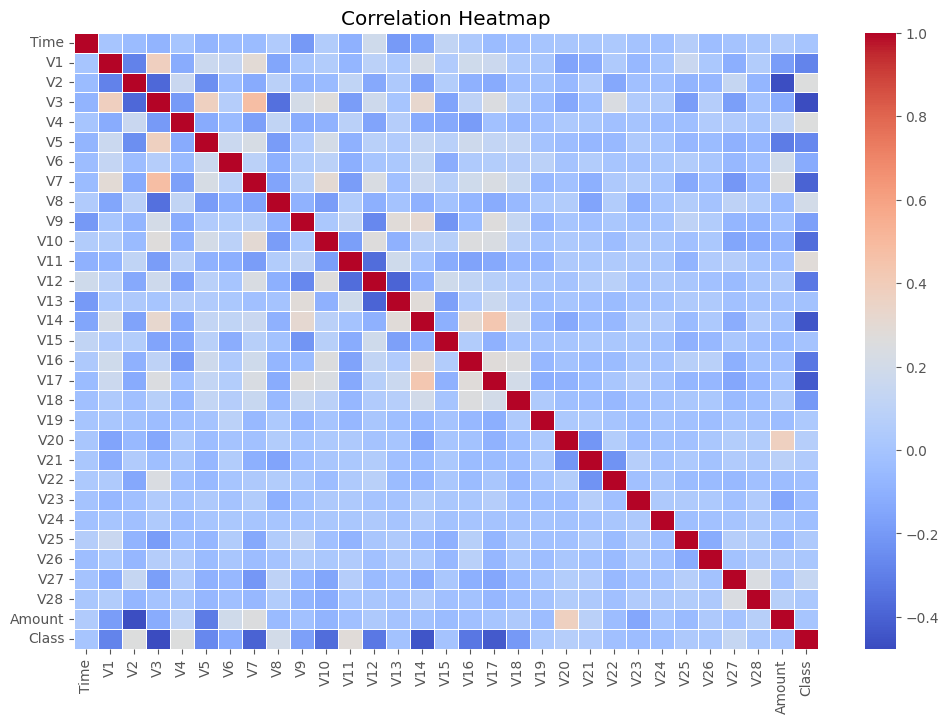

In [15]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
# Features Most Correlated with Fraud

correlation = df.corr()["Class"].sort_values()

print(correlation)

V3       -0.476294
V14      -0.441833
V17      -0.426317
V7       -0.395674
V10      -0.363563
V16      -0.327048
V12      -0.321828
V1       -0.285602
V5       -0.263605
V18      -0.201947
V9       -0.175465
V6       -0.124538
V23      -0.041799
V24      -0.029307
V22      -0.024029
V13      -0.009892
V15      -0.009043
Time      0.003817
Amount    0.006824
V26       0.017745
V28       0.022922
V19       0.029348
V25       0.032147
V21       0.042885
V20       0.065875
V27       0.135965
V8        0.200598
V2        0.259959
V4        0.261522
V11       0.284211
Class     1.000000
Name: Class, dtype: float64


# Business Insights

### Key Findings

- Fraud transactions represent a very small percentage of all transactions.
- Most transactions are legitimate.
- Fraudulent transactions have different patterns compared to normal transactions.
- Transaction amount alone is not enough to identify fraud.
- Correlation analysis helps identify variables related to fraudulent behavior.

### Recommendation

Banks should continuously monitor suspicious transactions and combine multiple features to improve fraud detection systems.

# Conclusion

This project analyzed credit card transactions to better understand fraud behavior.

The analysis showed that fraudulent transactions are extremely rare compared to legitimate ones. Data visualization and correlation analysis provided useful insights that can support fraud detection systems.

This project demonstrates practical data analysis skills using Python, Pandas, Matplotlib, and Seaborn.